LOADING THE DATASET 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("../data/delhi_ncr_aqi_dataset.csv")

print(df.shape)
df.head()

(201664, 25)


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [3]:
df.info()
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  float64
 18  o3  

CONVERTING THE DATETIME AND DATE COLUMN FROM OBJECT INTO DATETIME FORMAT 

In [4]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("datetime").reset_index(drop=True)

# Filter Delhi only
df = df[df["city"] == "Delhi"].copy()
df = df.sort_values("datetime").reset_index(drop=True)

In [5]:
df = df.drop(columns=["aqi_category", "station", "city"])

In [6]:
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["weekday"] = df["datetime"].dt.weekday

Checking Each column Distribution

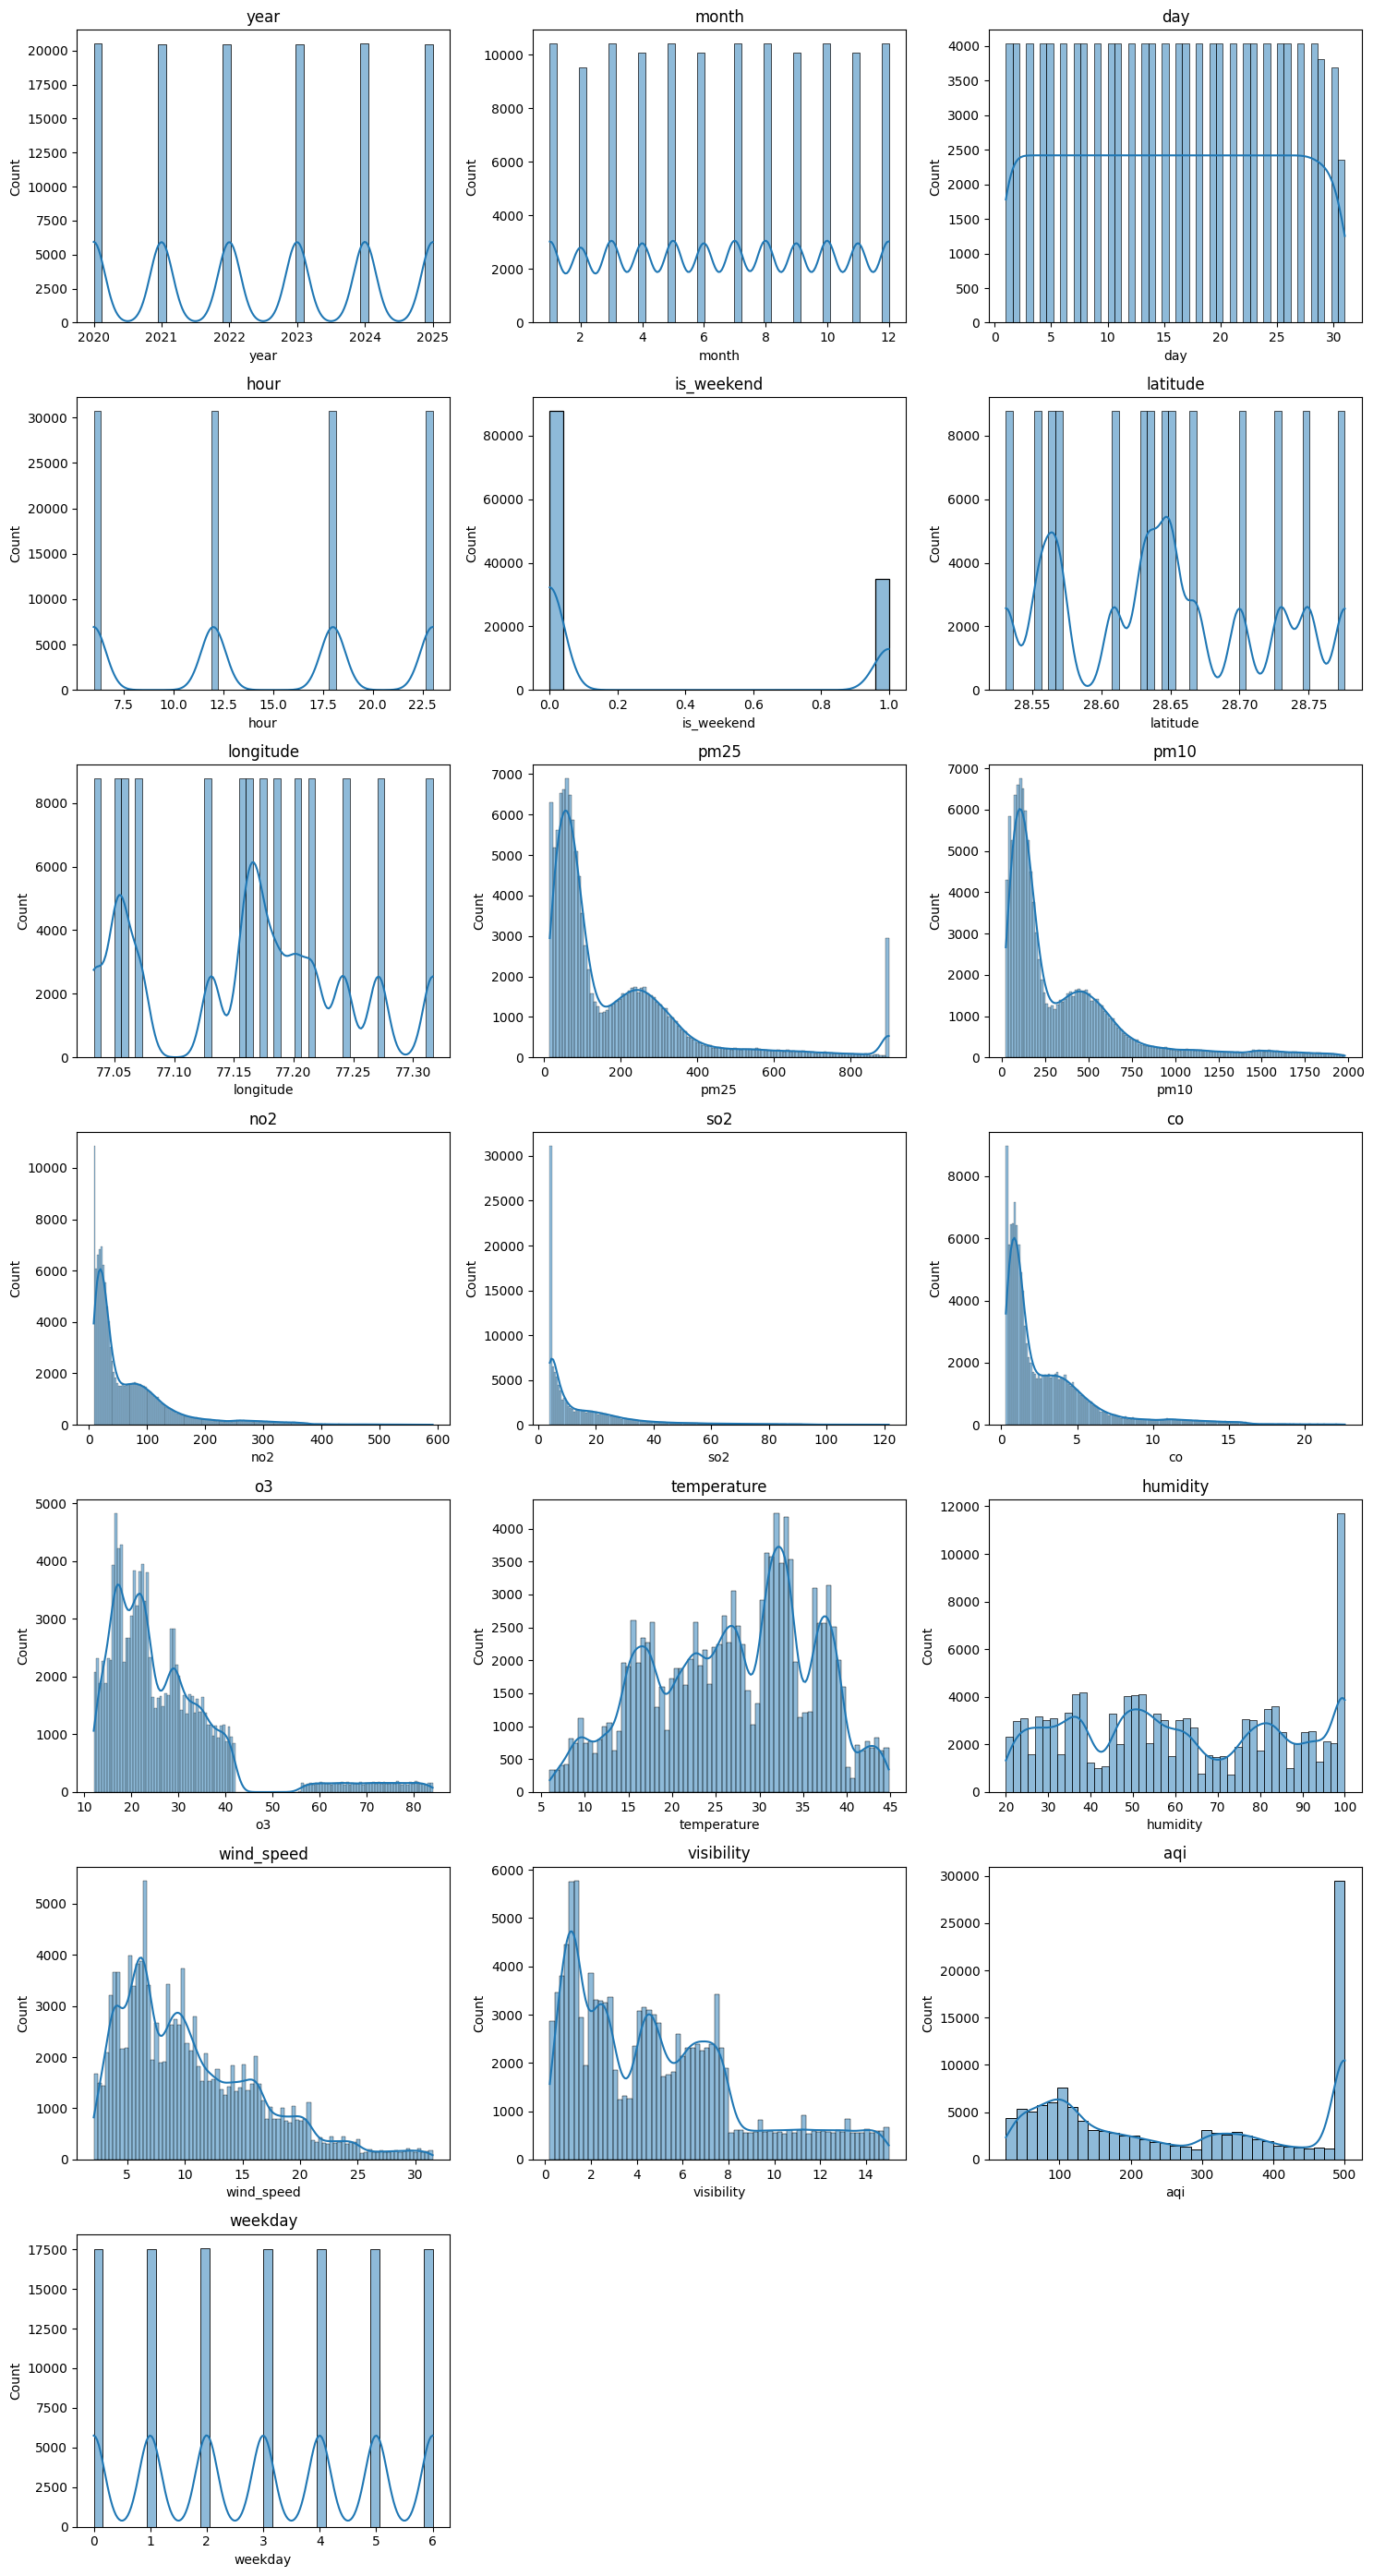

In [7]:
num_cols=df.select_dtypes(include='number').columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

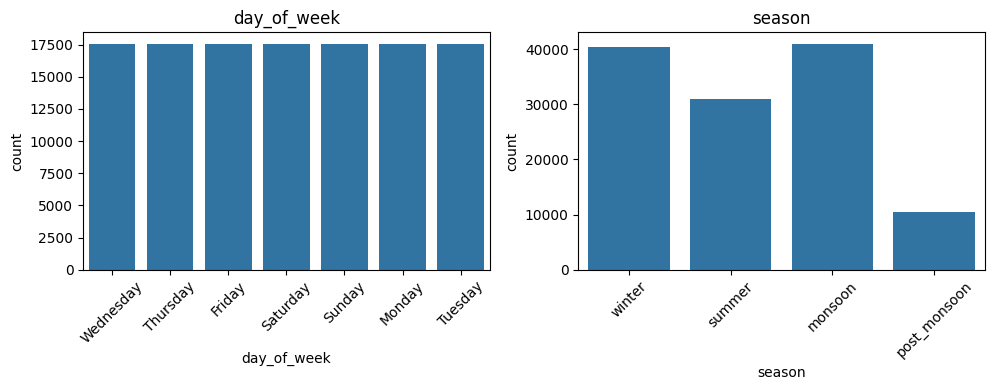

In [8]:
cat_cols = df.select_dtypes(include='object').columns
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Feature VS Numeric Cols

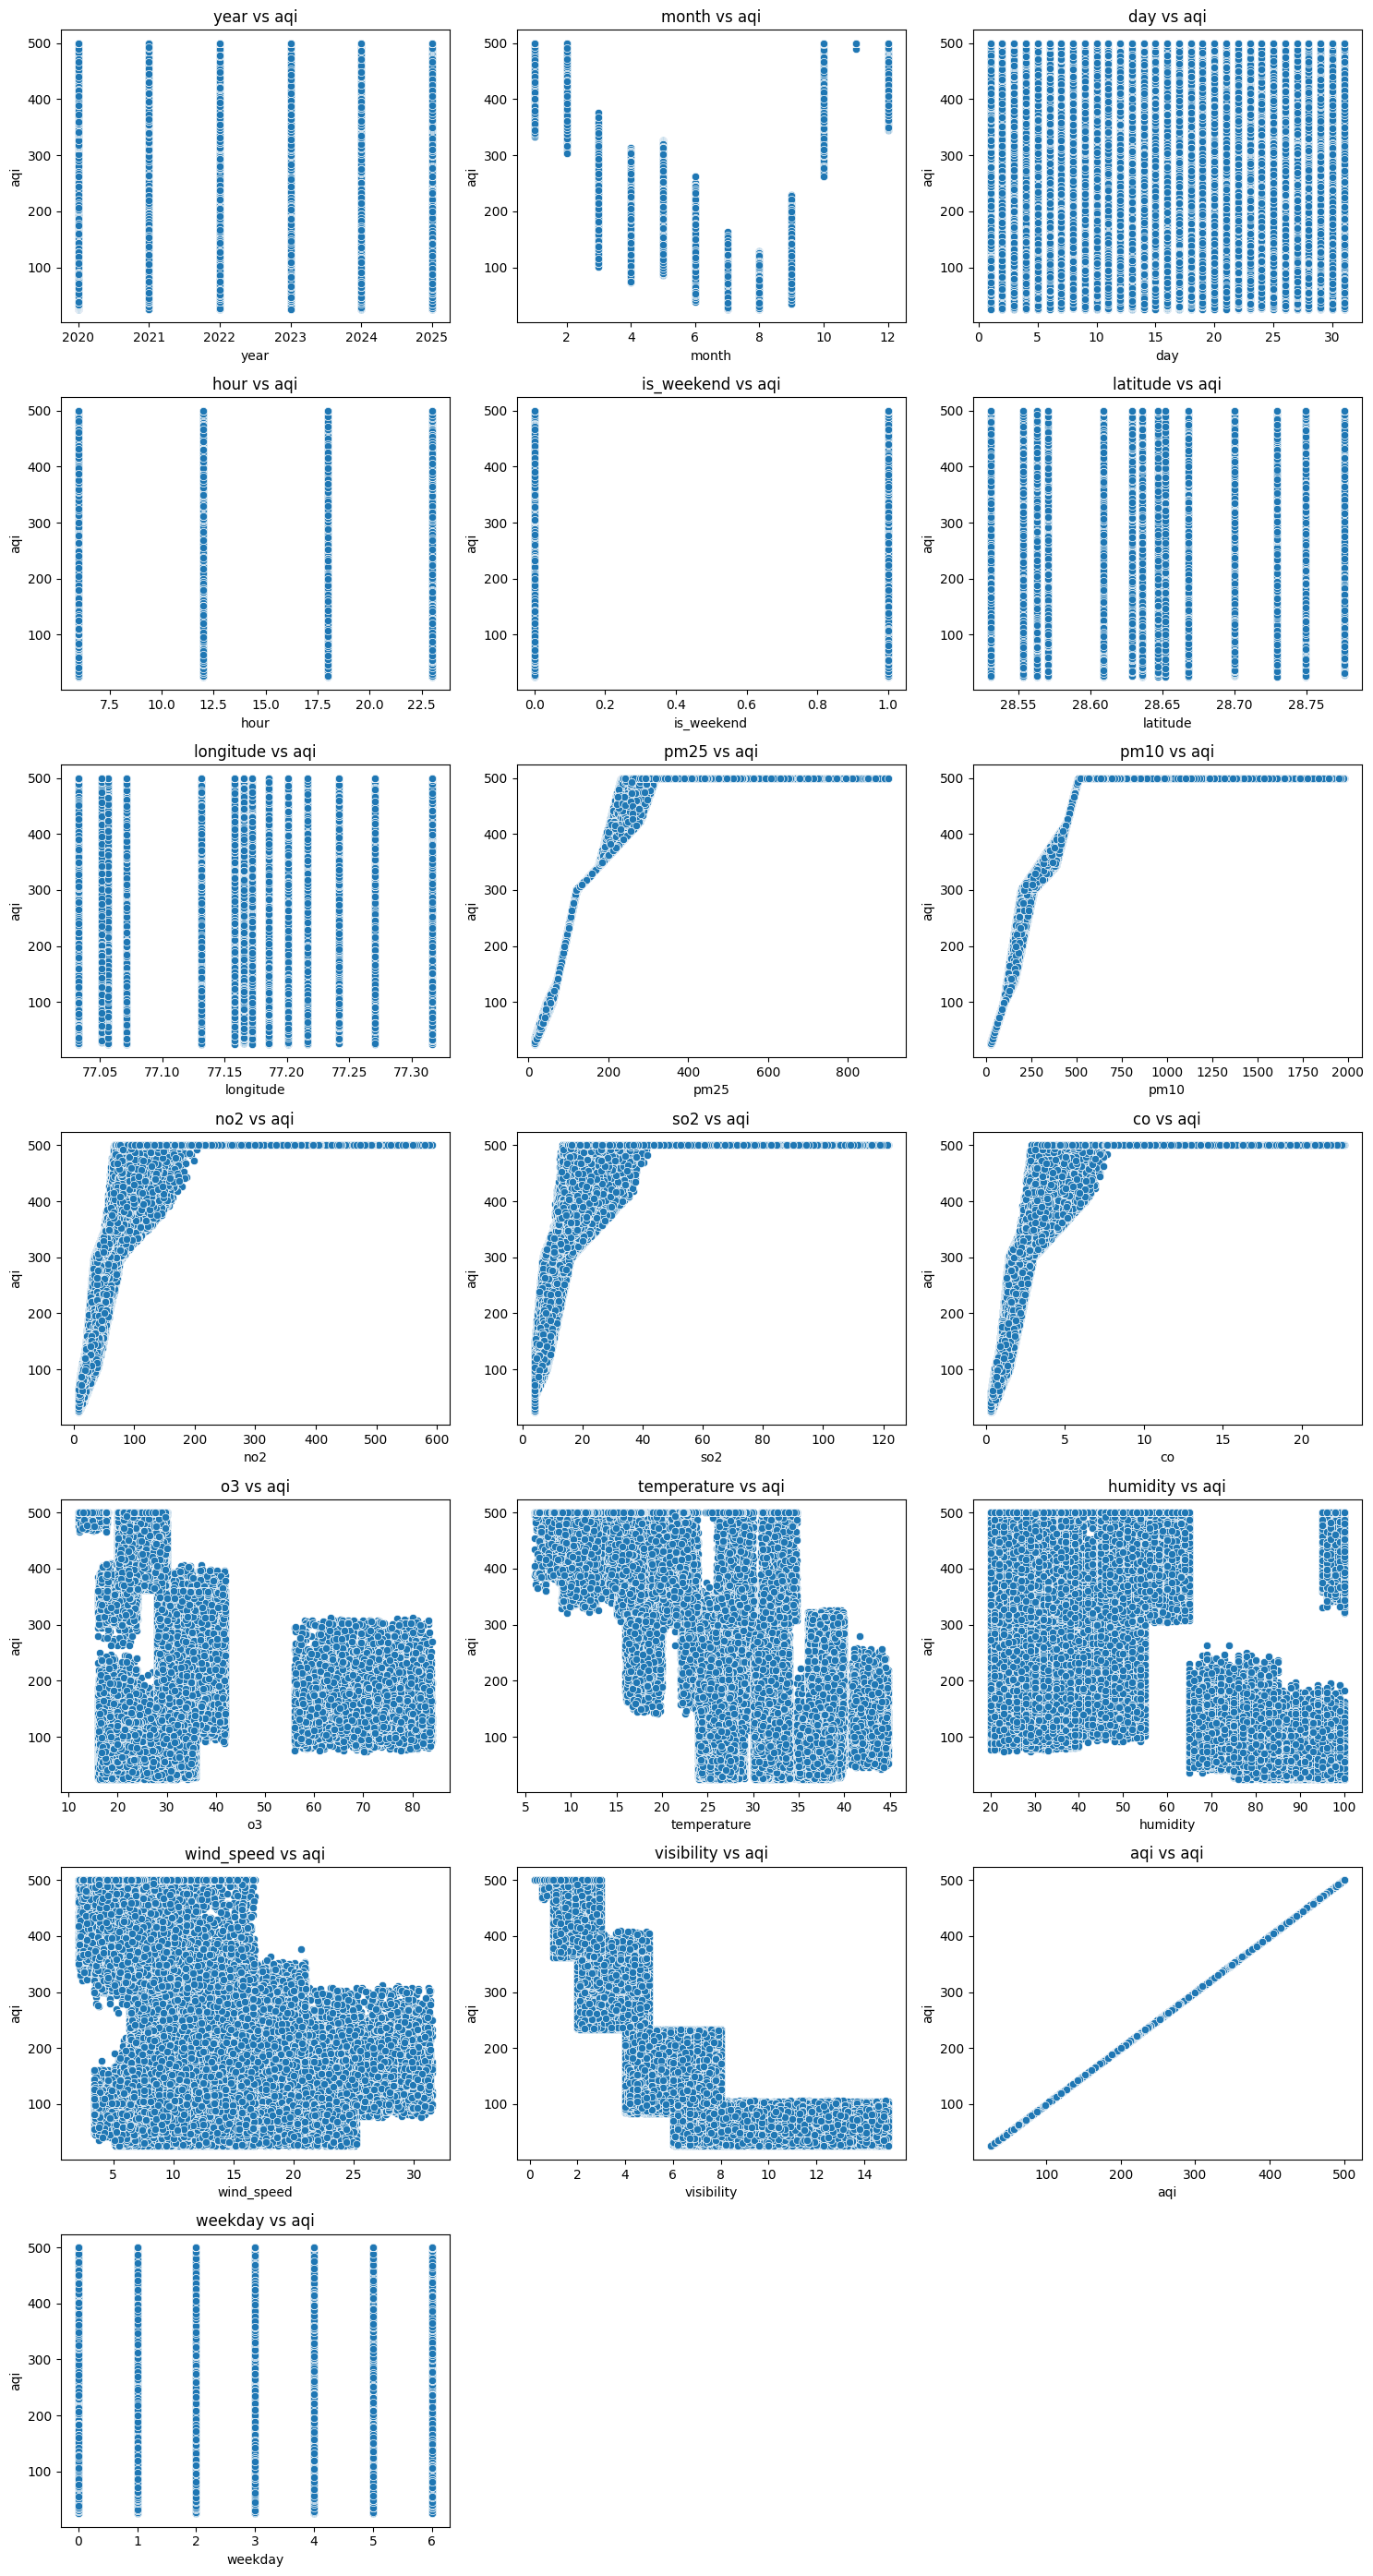

In [9]:
target='aqi'
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.scatterplot(x=df[col], y=df[target], ax=axes[i])
    axes[i].set_title(f"{col} vs {target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Checking for Outliers (Box Plot)

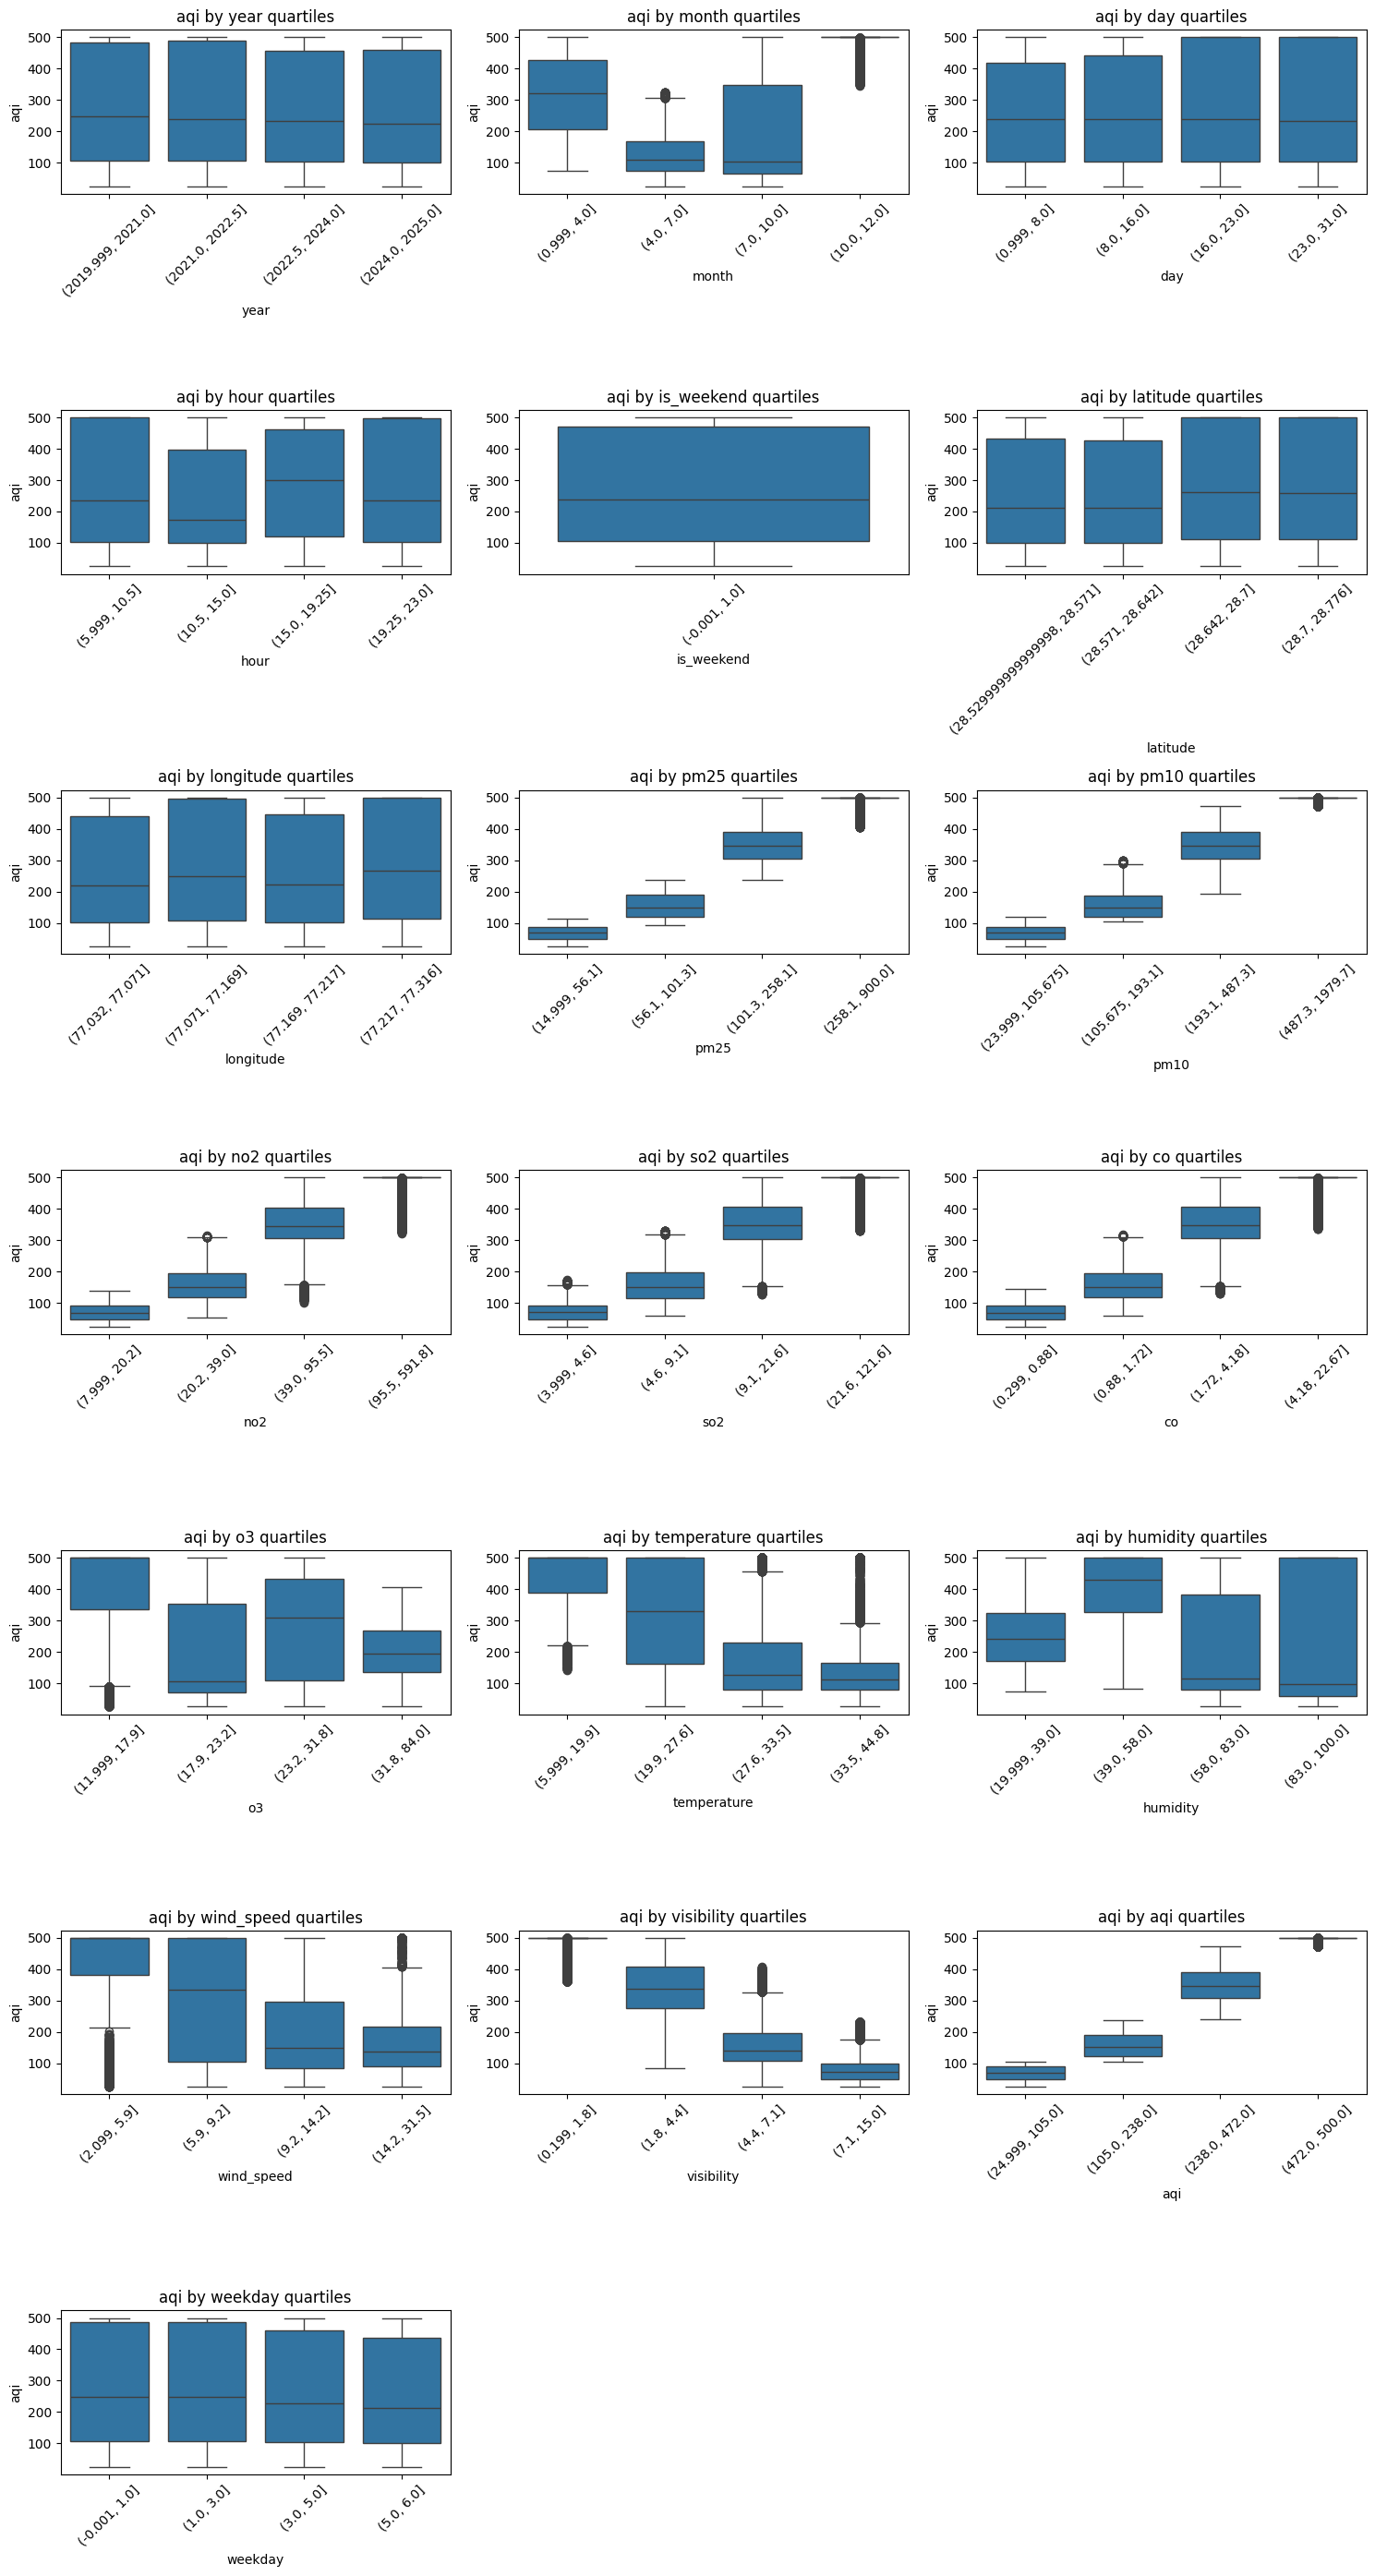

In [10]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(
        x=pd.qcut(df[col], q=4, duplicates='drop'),
        y=df[target],
        ax=axes[i]
    )
    axes[i].set_title(f"{target} by {col} quartiles")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Categorical Features VS Target

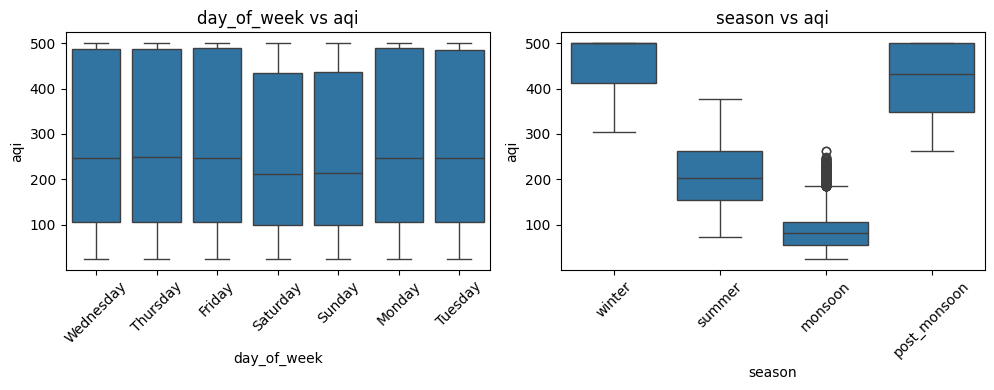

In [11]:
target = 'aqi'
cat_cols = df.select_dtypes(include='object').columns
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df[target], ax=axes[i])
    axes[i].set_title(f"{col} vs {target}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Correlation Matrix 

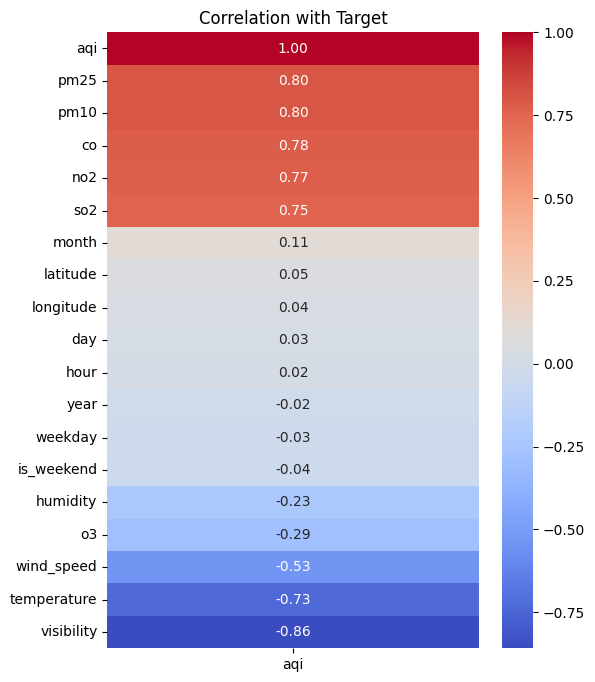

In [12]:
corr_with_target = df[num_cols].corr()[target].sort_values(ascending=False)
plt.figure(figsize=(6,8))
sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation with Target")
plt.show()

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Keep only non-outliers
df_clean = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
                (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [14]:
print("Original:", df.shape)
print("After removing outliers:", df_clean.shape)

Original: (122752, 23)
After removing outliers: (104465, 23)


In [ ]:
df_clean.to_csv("cleaned_data.csv",index=False)